In [1]:


import os
import re
import string
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import SelectKBest, chi2, f_classif, f_regression



from sklearn.feature_extraction.text import TfidfVectorizer

try:
    import nltk
    from nltk.corpus import stopwords
    from nltk.tokenize import word_tokenize

    _resources = [("tokenizers/punkt", "punkt"),
                  ("tokenizers/punkt_tab", "punkt_tab"),
                  ("corpora/stopwords", "stopwords")]
    for _path, _name in _resources:
        try:
            nltk.data.find(_path)
        except LookupError:
            try:
                nltk.download(_name, quiet=True)
            except Exception:
                pass
    NLTK_AVAILABLE = True
except Exception as _e:
    print(f"[WARNING] NLTK not fully available ({_e}). "
          "process_text_dataset() will fall back to a built-in stopword list.")
    NLTK_AVAILABLE = False

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers, models
    TENSORFLOW_AVAILABLE = True
except Exception as _e:
    print(f"[WARNING] TensorFlow not available ({_e}). "
          "process_image_dataset() will not work until TensorFlow is installed.")
    TENSORFLOW_AVAILABLE = False

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Cell 1 complete: all libraries imported successfully.")

[WARNING] NLTK not fully available (No module named 'nltk'). process_text_dataset() will fall back to a built-in stopword list.
[WARNING] TensorFlow not available (No module named 'tensorflow'). process_image_dataset() will not work until TensorFlow is installed.
Cell 1 complete: all libraries imported successfully.


In [2]:
def process_text_dataset(dataset_path, text_column, target_column,
                          max_features=5000, k_features="auto",
                          test_size=0.2, random_state=RANDOM_STATE,
                          verbose=True):
  

    def log(msg):
        if verbose:
            print(msg)


        "the", "a", "an", "is", "are", "was", "were", "be", "been", "am",
        "i", "you", "he", "she", "it", "we", "they", "this", "that",
        "to", "of", "in", "on", "for", "and", "or", "but", "with", "as",
        "at", "by", "from", "not", "no", "so", "if", "then", "than",
        "too", "very", "can", "will", "just", "do", "does", "did", "my",
        "your", "our", "their", "im", "its",

    log("=" * 72)
    log("STEP 1: LOADING DATASET")
    log("=" * 72)
    try:
        if dataset_path.lower().endswith(".csv"):
            df = pd.read_csv(dataset_path, encoding="latin-1")
        elif dataset_path.lower().endswith((".xlsx", ".xls")):
            df = pd.read_excel(dataset_path)
        else:
            raise ValueError("Unsupported file format. Please use .csv, .xlsx or .xls")
    except FileNotFoundError:
        raise FileNotFoundError(f"Could not find a file at: {dataset_path}")
    except Exception as e:
        raise RuntimeError(f"Failed to load dataset: {e}")

    for col in (text_column, target_column):
        if col not in df.columns:
            raise ValueError(f"Column '{col}' not found. Available columns: {list(df.columns)}")

    df = df[[text_column, target_column]].dropna().reset_index(drop=True)
    log(f"Dataset loaded successfully. Shape (rows, cols): {df.shape}")
   
    df = df.dropna(subset=[target_column])
    before = len(df)
   
    valid_labels = df[target_column].value_counts()
    valid_labels = valid_labels[valid_labels > 1].index

    df = df[df[target_column].isin(valid_labels)].copy()
    removed = before - len(df)
    if removed > 0:
        log(f"Removed {removed} row(s) with invalid or singleton target classes.")
   
    log("\n" + "=" * 72)
    log("STEP 2: EXPLORATORY DATA ANALYSIS")
    log("=" * 72)

    log(f"\nMissing values:\n{df.isnull().sum()}")
    log(f"\nDuplicate rows: {df.duplicated().sum()}")
    log(f"\nClass distribution:\n{df[target_column].value_counts()}")

    df["_text_length"] = df[text_column].astype(str).apply(len)
    log(f"\nText length statistics:\n{df['_text_length'].describe()}")

    if verbose:
        plt.figure()
        df["_text_length"].hist(bins=30, color="steelblue")
        plt.title("Distribution of Text Length (characters)")
        plt.xlabel("Number of characters")
        plt.ylabel("Frequency")
        plt.tight_layout()
        plt.show()

        plt.figure()
        df[target_column].value_counts().plot(kind="bar", color="seagreen")
        plt.title(f"Class Distribution: {target_column}")
        plt.ylabel("Count")
        plt.tight_layout()
        plt.show()

        if df[target_column].nunique() <= 10:
            plt.figure()
            sns.boxplot(data=df, x=target_column, y="_text_length")
            plt.title("Text Length by Class")
            plt.tight_layout()
            plt.show()

    df = df.drop(columns=["_text_length"])


    log("\n" + "=" * 72)
    log("STEP 3: TEXT CLEANING / STOPWORD REMOVAL / TOKENIZATION")
    log("=" * 72)

    if NLTK_AVAILABLE:
        stop_words = set(stopwords.words("english"))
    else:
        stop_words = BASIC_STOPWORDS

    def clean_and_tokenize(raw_text):
        """Nested helper: lowercase -> strip punctuation/numbers -> tokenize
        -> remove stopwords. Returns a single cleaned string (tokens joined
        by spaces) ready for TF-IDF vectorization."""
        text = str(raw_text).lower()
        text = re.sub(r"http\S+|www\S+", " ", text)          
        text = re.sub(r"[^a-z\s]", " ", text)                
        text = text.translate(str.maketrans("", "", string.punctuation))

        if NLTK_AVAILABLE:
            try:
                tokens = word_tokenize(text)
            except Exception:
                tokens = text.split()
        else:
            tokens = text.split()

        tokens = [tok for tok in tokens if tok not in stop_words and len(tok) > 1]
        return " ".join(tokens)

    df["_clean_text"] = df[text_column].apply(clean_and_tokenize)
   
    before = df.shape[0]
    df = df[df["_clean_text"].str.strip() != ""].reset_index(drop=True)
    log(f"Cleaned {before} text entries (dropped {before - df.shape[0]} that became empty).")
    log(f"Example -> before: {df[text_column].iloc[0]!r}")
    log(f"Example -> after : {df['_clean_text'].iloc[0]!r}")

  
    target_encoder = None
    y = df[target_column]
    if not pd.api.types.is_numeric_dtype(y):
        target_encoder = LabelEncoder()
        y = pd.Series(target_encoder.fit_transform(y.astype(str)), index=y.index)
        log(f"\nEncoded target classes: {list(target_encoder.classes_)}")
    n_unique_target = y.nunique()

    log("\n" + "=" * 72)
    log("STEP 5: TF-IDF VECTORIZATION")
    log("=" * 72)

    vectorizer = TfidfVectorizer(max_features=max_features)
    X_tfidf = vectorizer.fit_transform(df["_clean_text"])
    log(f"TF-IDF matrix shape: {X_tfidf.shape} (rows x vocabulary size)")


    log("\n" + "=" * 72)
    log("STEP 6: FEATURE SELECTION")
    log("=" * 72)

    n_features_available = X_tfidf.shape[1]
    k = min(300, n_features_available) if k_features == "auto" else min(k_features, n_features_available)

    try:

        selector = SelectKBest(score_func=chi2, k=k)
        X_selected = selector.fit_transform(X_tfidf, y)
        log(f"Selected top {k} TF-IDF feature(s) using the Chi-Square test.")
    except Exception as e:
        log(f"[WARNING] Feature selection failed ({e}). Using the full TF-IDF matrix instead.")
        X_selected = X_tfidf

    log("\n" + "=" * 72)
    log("STEP 7: TRAIN / TEST SPLIT")
    log("=" * 72)

    print("\nTarget value counts:")
    print(pd.Series(y).value_counts())

    print("\nUnique target values:")
    print(np.unique(y))

    X_train, X_test, y_train, y_test = train_test_split(
        X_selected, y, test_size=test_size, random_state=random_state, stratify=y
    )
    log(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")

    # ------------------------------------------------------------------
   

    return {
        "vectorizer": vectorizer,
        "task_type": "classification",
        "target_encoder": target_encoder,
        "X_train": X_train, "X_test": X_test,
        "y_train": y_train, "y_test": y_test,
    }

In [3]:
def process_tabular_dataset(dataset_path, target_column,
                             id_columns=None, k_features="auto",
                             test_size=0.2, val_size=0.1,
                             random_state=RANDOM_STATE, verbose=True):
    

    def log(msg):
      
        if verbose:
            print(msg)

    # ------------------------------------------------------------------
    # STEP 1: LOADING
    # ------------------------------------------------------------------
    log("=" * 72)
    log("STEP 1: LOADING DATASET")
    log("=" * 72)
    try:
        if dataset_path.lower().endswith(".csv"):
            df = pd.read_csv(dataset_path)
        elif dataset_path.lower().endswith((".xlsx", ".xls")):
            df = pd.read_excel(dataset_path)
        else:
            raise ValueError("Unsupported file format. Please use .csv, .xlsx or .xls")
    except FileNotFoundError:
        raise FileNotFoundError(f"Could not find a file at: {dataset_path}")
    except Exception as e:
        raise RuntimeError(f"Failed to load dataset: {e}")

    if target_column not in df.columns:
        raise ValueError(
            f"target_column '{target_column}' not found in dataset. "
            f"Available columns: {list(df.columns)}"
        )

    log(f"Dataset loaded successfully. Shape (rows, cols): {df.shape}")


    log("\n" + "=" * 72)
    log("STEP 2: EXPLORATORY DATA ANALYSIS")
    log("=" * 72)

    log(f"\nShape: {df.shape}")
    log("\nData types:\n" + str(df.dtypes))

    missing = df.isnull().sum()
    log("\nMissing values per column:")
    log(missing[missing > 0] if missing.sum() > 0 else "  None found.")

    log(f"\nDuplicate rows: {df.duplicated().sum()}")
    log("\nSummary statistics (numeric columns):\n" + str(df.describe()))

    numeric_cols_eda = df.select_dtypes(include=np.number).columns.tolist()
    categorical_cols_eda = df.select_dtypes(exclude=np.number).columns.tolist()

    if verbose:
       
        if numeric_cols_eda:
            df[numeric_cols_eda].hist(figsize=(14, 10), bins=20, color="steelblue")
            plt.suptitle("Histograms of Numeric Features")
            plt.tight_layout()
            plt.show()

      
        for col in categorical_cols_eda:
            if col != target_column and 1 < df[col].nunique() <= 15:
                plt.figure()
                df[col].value_counts().plot(kind="bar", color="salmon")
                plt.title(f"Bar Chart: {col}")
                plt.ylabel("Count")
                plt.tight_layout()
                plt.show()

      
        scatter_cols = [c for c in numeric_cols_eda if c != target_column][:4]
        if len(scatter_cols) >= 2:
            sns.pairplot(df[scatter_cols])
            plt.suptitle("Scatter Plots of Numeric Features", y=1.02)
            plt.show()

     
        if len(numeric_cols_eda) > 1:
            plt.figure(figsize=(10, 8))
            sns.heatmap(df[numeric_cols_eda].corr(), annot=True, fmt=".2f", cmap="coolwarm")
            plt.title("Correlation Heatmap")
            plt.tight_layout()
            plt.show()

        if numeric_cols_eda:
            plt.figure(figsize=(14, 6))
            df[numeric_cols_eda].boxplot(rot=45)
            plt.title("Box Plots of Numeric Features")
            plt.tight_layout()
            plt.show()

        
        if df[target_column].nunique() <= 20:
            plt.figure()
            df[target_column].value_counts().plot(kind="bar", color="seagreen")
            plt.title(f"Class Distribution: {target_column}")
            plt.tight_layout()
            plt.show()

    log("\n" + "=" * 72)
    log("STEP 3: DATA PREPROCESSING")
    log("=" * 72)

    df = df.copy()


    before = df.shape[0]
    df = df.drop_duplicates()
    log(f"Removed {before - df.shape[0]} duplicate row(s).")

  
    def detect_id_columns(frame, target):
        """A column is treated as an identifier if its name contains 'id'
        or if every single value in it is unique (like a row number)."""
        detected = []
        for col in frame.columns:
            if col == target:
                continue
            looks_like_id = "id" in col.lower()
            is_fully_unique = frame[col].nunique() == frame.shape[0]
            if looks_like_id or is_fully_unique:
                detected.append(col)
        return detected

    cols_to_drop = id_columns if id_columns is not None else detect_id_columns(df, target_column)
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)
        log(f"Dropped identifier column(s): {cols_to_drop}")
    else:
        log("No identifier columns detected.")

    # --- Handle missing values ---
    # Numeric columns are filled with the median (robust to outliers).
    # Categorical columns are filled with the most frequent value (mode).
    numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c != target_column]
    categorical_cols = [c for c in df.select_dtypes(exclude=np.number).columns if c != target_column]

    if numeric_cols and df[numeric_cols].isnull().sum().sum() > 0:
        num_imputer = SimpleImputer(strategy="median")
        df[numeric_cols] = num_imputer.fit_transform(df[numeric_cols])
        log("Filled missing numeric values using column medians.")

    if categorical_cols and df[categorical_cols].isnull().sum().sum() > 0:
        cat_imputer = SimpleImputer(strategy="most_frequent")
        df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])     
        log("Filled missing categorical values using column modes.")

    # Rows with a missing target can't be used for training, so drop them.
    before = df.shape[0]
    df = df.dropna(subset=[target_column])
    if before != df.shape[0]:
        log(f"Dropped {before - df.shape[0]} row(s) with a missing target value.")

    # --- Automatically decide: classification or regression? ---
    target_series = df[target_column]
    is_numeric_target = pd.api.types.is_numeric_dtype(target_series)
    n_unique_target = target_series.nunique()

  
    if (not is_numeric_target) or (n_unique_target <= 20):
        task_type = "classification"
    else:
        task_type = "regression"
    log(f"Automatically detected ML task type: {task_type.upper()}")

    # --- Encode the target column (classification with text labels only) ---
    target_encoder = None
    if task_type == "classification" and not pd.api.types.is_numeric_dtype(target_series):
        target_encoder = LabelEncoder()
        df[target_column] = target_encoder.fit_transform(df[target_column].astype(str))
        log(f"Encoded target classes: {list(target_encoder.classes_)}")

    # --- One-hot encode categorical feature columns ---
    feature_categorical_cols = [c for c in df.select_dtypes(exclude=np.number).columns if c != target_column]
    if feature_categorical_cols:
        df = pd.get_dummies(df, columns=feature_categorical_cols, drop_first=True)
        log(f"One-hot encoded categorical feature column(s): {feature_categorical_cols}")

    # --- Split into features (X) and target (y), then scale numeric features ---
    X = df.drop(columns=[target_column])
    y = df[target_column]

    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
    log("Standardized all features to zero mean and unit variance.")

    # ------------------------------------------------------------------
    # STEP 4: FEATURE SELECTION
    # ------------------------------------------------------------------
    log("\n" + "=" * 72)
    log("STEP 4: FEATURE SELECTION")
    log("=" * 72)

    n_features_available = X_scaled.shape[1]
    k = min(10, n_features_available) if k_features == "auto" else min(k_features, n_features_available)

    try:
        
        score_func = f_classif if task_type == "classification" else f_regression
        selector = SelectKBest(score_func=score_func, k=k)
        X_selected = selector.fit_transform(X_scaled, y)
        selected_mask = selector.get_support()
        selected_features = X_scaled.columns[selected_mask].tolist()
        X_selected = pd.DataFrame(X_selected, columns=selected_features, index=X_scaled.index)
        method_name = "ANOVA F-test" if task_type == "classification" else "F-regression"
        log(f"Selected top {k} feature(s) using {method_name}: {selected_features}")
    except Exception as e:
        log(f"[WARNING] Feature selection failed ({e}). Falling back to using all features.")
        X_selected = X_scaled
        selected_features = X_scaled.columns.tolist()


    log("\n" + "=" * 72)
    log("STEP 5: TRAIN / VALIDATION / TEST SPLIT")
    log("=" * 72)

    stratify_arg = y if task_type == "classification" else None
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_selected, y, test_size=test_size, random_state=random_state, stratify=stratify_arg
    )
    
    relative_val_size = val_size / (1 - test_size)
    stratify_arg2 = y_train_full if task_type == "classification" else None
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=relative_val_size,
        random_state=random_state, stratify=stratify_arg2
    )
    log(f"Train size: {X_train.shape[0]} | Validation size: {X_val.shape[0]} | Test size: {X_test.shape[0]}")

    # ------------------------------------------------------------------


    return {
        "task_type": task_type,
        "feature_names": selected_features,
        "scaler": scaler,
        "target_encoder": target_encoder,
        "X_train": X_train, "X_val": X_val, "X_test": X_test,
        "y_train": y_train, "y_val": y_val, "y_test": y_test,
    }

In [4]:
def process_image_dataset(
    csv_path,
    image_column,
    label_column,
    image_size=(64, 64),
    test_size=0.2,
    validation_size=0.1,
    random_state=42,
    verbose=True
):
  

    import os
    import cv2
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt

    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import LabelEncoder

    def log(message):
        if verbose:
            print(message)

    log("=" * 72)
    log("IMAGE DATASET PROCESSING")
    log("=" * 72)

    # ------------------------------------------------------------------
    # STEP 1 : LOAD DATASET
    # ------------------------------------------------------------------

    log("\nSTEP 1: LOADING IMAGE DATASET")
    log("=" * 72)

    df = pd.read_csv(csv_path)

    df.columns = df.columns.str.strip()

    if image_column not in df.columns:
        raise ValueError(f"Image column '{image_column}' not found.")

    if label_column not in df.columns:
        raise ValueError(f"Label column '{label_column}' not found.")

    images = []
    labels = []

    csv_directory = os.path.dirname(csv_path)

    for _, row in df.iterrows():

        image_path = str(row[image_column]).strip()

        # Handle relative paths
        if not os.path.isabs(image_path):
            image_path = os.path.join(csv_directory, image_path)

        image = cv2.imread(image_path)

        if image is None:
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image = cv2.resize(image, image_size)

        images.append(image)

        labels.append(row[label_column])

    if len(images) == 0:
        raise ValueError(
            "No images were loaded. "
            "Please verify the image paths stored in the CSV."
        )

    X = np.array(images, dtype=np.float32)

    y = np.array(labels)

    log(f"Loaded {len(X)} images successfully.")

    # ------------------------------------------------------------------
    # STEP 2 : EDA
    # ------------------------------------------------------------------

    log("\n" + "=" * 72)
    log("STEP 2: IMAGE EDA")
    log("=" * 72)

    log(f"Image Shape : {X.shape}")
    log(f"Total Classes : {len(np.unique(y))}")

    unique, counts = np.unique(y, return_counts=True)

    plt.figure(figsize=(8,4))
    plt.bar(unique.astype(str), counts)
    plt.title("Class Distribution")
    plt.xticks(rotation=90)
    plt.show()

    plt.figure(figsize=(12,6))

    samples = min(10, len(X))

    for i in range(samples):

        plt.subplot(2,5,i+1)

        plt.imshow(X[i].astype(np.uint8))

        plt.title(str(y[i]))

        plt.axis("off")

    plt.tight_layout()

    plt.show()


    log("\n" + "=" * 72)
    log("STEP 3: PREPROCESSING")
    log("=" * 72)

    X = X / 255.0

    log("Pixel values normalized to range [0,1].")

    encoder = LabelEncoder()

    y = encoder.fit_transform(y)

    log("Labels encoded successfully.")



    log("\n" + "=" * 72)
    log("STEP 4: FEATURE SELECTION")
    log("=" * 72)

    log("Skipped.")
    log("Reason: Feature selection techniques like Chi-Square and ANOVA")
    log("are generally not applicable to raw image pixels.")
    log("Image models automatically learn useful features.")

 

    log("\n" + "=" * 72)
    log("STEP 5: TRAIN / VALIDATION / TEST SPLIT")
    log("=" * 72)

    X_train, X_temp, y_train, y_temp = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    validation_ratio = validation_size / test_size

    X_val, X_test, y_val, y_test = train_test_split(
        X_temp,
        y_temp,
        test_size=1 - validation_ratio,
        random_state=random_state,
        stratify=y_temp
    )

    log(f"Training Images   : {len(X_train)}")
    log(f"Validation Images : {len(X_val)}")
    log(f"Testing Images    : {len(X_test)}")

    log("\nImage Dataset Processing Completed Successfully.")

    return {
        "task_type": "Image Classification",
        "label_encoder": encoder,
        "class_names": encoder.classes_,
        "X_train": X_train,
        "X_validation": X_val,
        "X_test": X_test,
        "y_train": y_train,
        "y_validation": y_val,
        "y_test": y_test,
    }

STEP 1: LOADING DATASET
Dataset loaded successfully. Shape (rows, cols): (5572, 2)

STEP 2: EXPLORATORY DATA ANALYSIS

Missing values:
Message     0
Category    0
dtype: int64

Duplicate rows: 415

Class distribution:
Category
ham     4825
spam     747
Name: count, dtype: int64

Text length statistics:
count    5572.000000
mean       80.494616
std        59.998745
min         2.000000
25%        36.000000
50%        61.000000
75%       122.000000
max       910.000000
Name: _text_length, dtype: float64


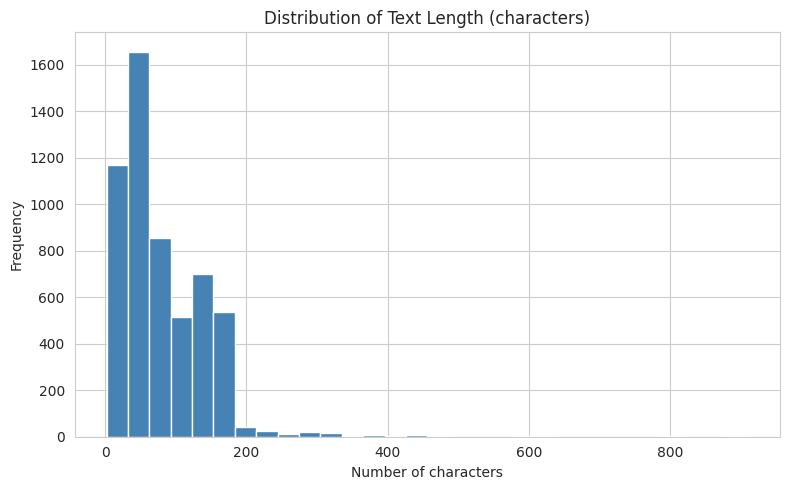

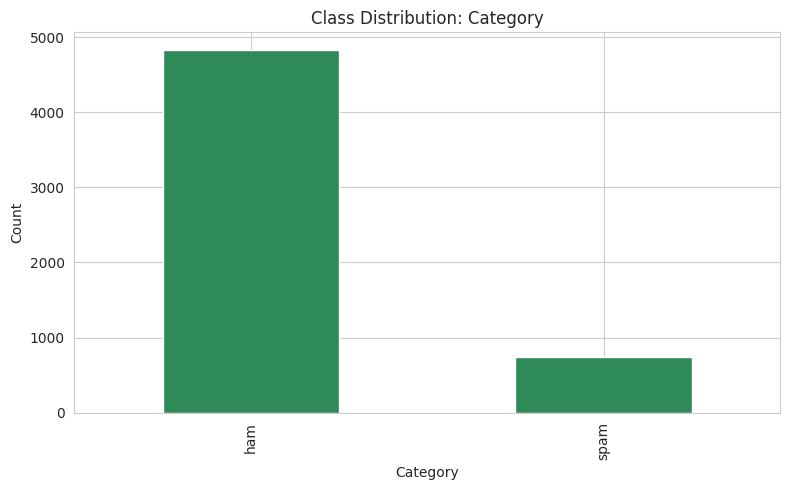

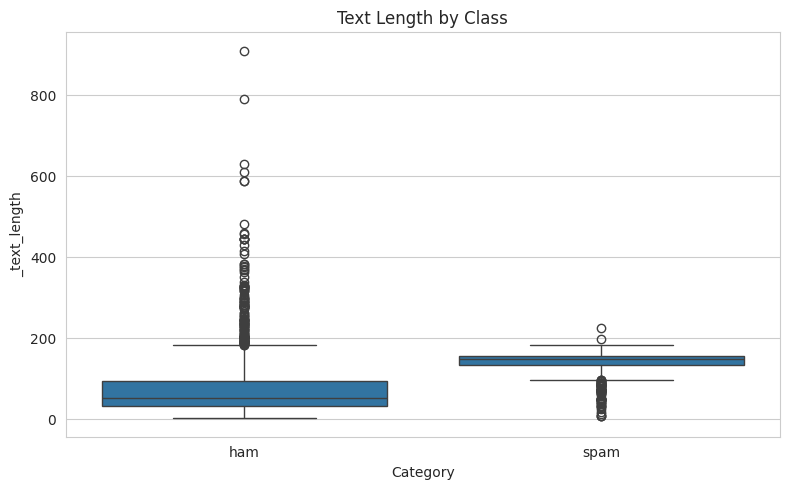


STEP 3: TEXT CLEANING / STOPWORD REMOVAL / TOKENIZATION
Cleaned 5572 text entries (dropped 7 that became empty).
Example -> before: 'Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...'
Example -> after : 'go until jurong point crazy available only bugis great world la buffet cine there got amore wat'

Encoded target classes: ['ham', 'spam']

STEP 5: TF-IDF VECTORIZATION
TF-IDF matrix shape: (5565, 5000) (rows x vocabulary size)

STEP 6: FEATURE SELECTION
Selected top 300 TF-IDF feature(s) using the Chi-Square test.

STEP 7: TRAIN / TEST SPLIT

Target value counts:
0    4818
1     747
Name: count, dtype: int64

Unique target values:
[0 1]
Train size: 4452 | Test size: 1113

Processing Completed Successfully!


In [7]:
# ============================================================================
# CELL 5: SELECT DATASET AND RUN THE APPROPRIATE PIPELINE
# ============================================================================

# -----------------------------
# Choose the dataset type
# -----------------------------
# Options:
# "tabular"
# "text"
# "image"

dataset_type = "text"

# ============================================================================
# TABULAR DATASET
# ============================================================================

if dataset_type == "tabular":

    dataset_path = "loan_approval_dataset.csv"      # Change to your dataset
    target_column = " loan_amount"               # Change to your target column

    result = process_tabular_dataset(
        dataset_path=dataset_path,
        target_column=target_column
    )

# ============================================================================
# TEXT DATASET
# ============================================================================

elif dataset_type == "text":

    dataset_path = "email.csv"

    text_column = "Message"
    target_column = "Category"

    result = process_text_dataset(
        dataset_path=dataset_path,
        text_column=text_column,
        target_column=target_column
    )

# ============================================================================
# IMAGE DATASET
# ============================================================================

elif dataset_type == "image":

    dataset_path = "english.csv"

    result = process_image_dataset(
        csv_path=dataset_path,
        image_column="image",
        label_column="label"
    )

# ============================================================================
# INVALID INPUT
# ============================================================================

else:
    raise ValueError(
        "dataset_type must be 'tabular', 'text', or 'image'."
    )

print("\nProcessing Completed Successfully!")